In [17]:
import json
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from pathlib import Path
from textwrap import fill

In [18]:
# 加载数据集
json_path = 'dataset_qwen_pe_top1000_captioned.json'
with open(json_path, 'r') as f:
    dataset = json.load(f)

In [19]:
print(f"数据集总样本数: {len(dataset)}")

数据集总样本数: 1000


In [20]:
def overlay_mask(image_path, mask_path, alpha=0.5):
    """将 mask 叠加到图像上"""
    try:
        # 加载图像和 mask
        image = Image.open(image_path).convert('RGB')
        mask = Image.open(mask_path).convert('L')  # 转换为灰度图
        
        # 调整 mask 尺寸以匹配图像
        if mask.size != image.size:
            mask = mask.resize(image.size, Image.LANCZOS)
        
        # 将图像和 mask 转换为 numpy 数组
        image_np = np.array(image)
        mask_np = np.array(mask)
        
        # 创建彩色 mask (红色)
        mask_colored = np.zeros_like(image_np)
        mask_colored[:, :, 0] = mask_np  # 红色通道
        
        # 叠加 mask
        mask_binary = (mask_np > 0).astype(float)
        mask_binary = np.expand_dims(mask_binary, axis=2)
        
        overlayed = image_np * (1 - alpha * mask_binary) + mask_colored * alpha * mask_binary
        overlayed = overlayed.astype(np.uint8)
        
        return Image.fromarray(overlayed)
    except Exception as e:
        print(f"处理图像时出错: {e}")
        return None

In [21]:
def visualize_sample(sample, index=None):
    """可视化一个样本（仅显示编辑前/后和 prompt）"""
    print("=" * 80)
    if index is not None:
        print(f"样本索引: {index}")
    edit_type = sample.get('edit_type', 'Unknown')
    print(f"编辑类型: {edit_type}")
    print(f"\nPrompt: {sample['prompt']}")
    print("=" * 80)
    
    base_path = Path('pico-banana-400k-subject_driven/openimages')
    mask_path = base_path / sample['back_mask']
    
    edit_images = sample['edit_image']
    if not isinstance(edit_images, list):
        edit_images = [edit_images]
    before_path = base_path / edit_images[0] if edit_images else None
    after_path = base_path / sample['image']
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes = axes.flatten()
    
    # 编辑前
    if before_path and before_path.exists():
        axes[0].imshow(Image.open(str(before_path)).convert('RGB'))
        axes[0].set_title('Input', fontsize=12, fontweight='bold')
    else:
        axes[0].set_title('编辑前缺失', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # 编辑后 + mask
    after_title = 'GT + Mask' if mask_path.exists() else '编辑后'
    if after_path.exists():
        if mask_path.exists():
            overlayed_after = overlay_mask(str(after_path), str(mask_path))
            if overlayed_after:
                axes[1].imshow(overlayed_after)
            else:
                axes[1].imshow(Image.open(str(after_path)).convert('RGB'))
        else:
            axes[1].imshow(Image.open(str(after_path)).convert('RGB'))
        axes[1].set_title(after_title, fontsize=12, fontweight='bold')
    else:
        axes[1].set_title('编辑后缺失', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

样本索引: 641
编辑类型: Add a new object to the scene

Prompt: Picture 1 is the image to modify. Insert a sleek, dark gray mouse below the 'Enter' key, matching the desk's texture and light source.


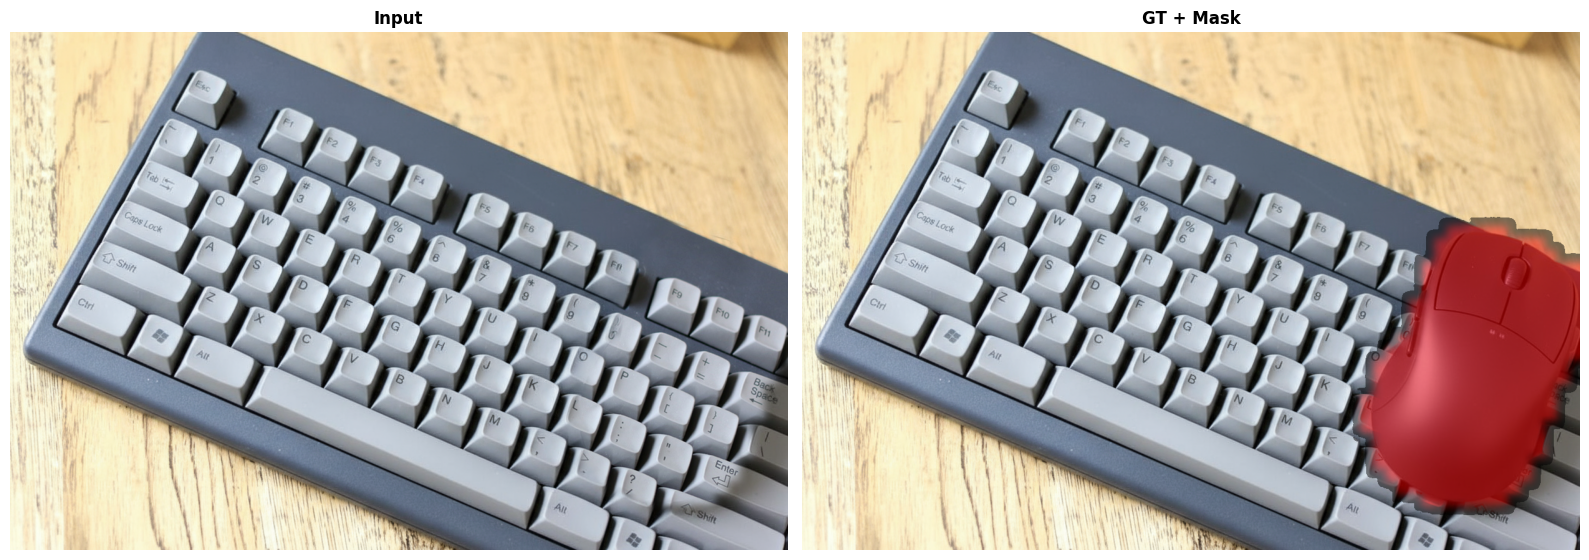

In [22]:
# 随机选择一个样本并可视化
random_index = random.randint(0, len(dataset) - 1)
random_sample = dataset[random_index]
visualize_sample(random_sample, random_index)


################################################################################
Edit Type: Add a new object to the scene (共 347 个样本，显示 1 个)
################################################################################

样本索引: 6
编辑类型: Add a new object to the scene

Prompt: Picture 1 is the image to modify. Add a perfectly halved, marinated soft-boiled egg (ajitsuke tamago) to the bowl, nestled gently into the broth among the noodles and existing toppings on the left side, ensuring its creamy, golden-orange yolk is visible and its glossy, light brown marinated white reflects the warm overhead light consistently with the other elements, maintaining the original image's shallow depth of field and inviting food photography aesthetic.


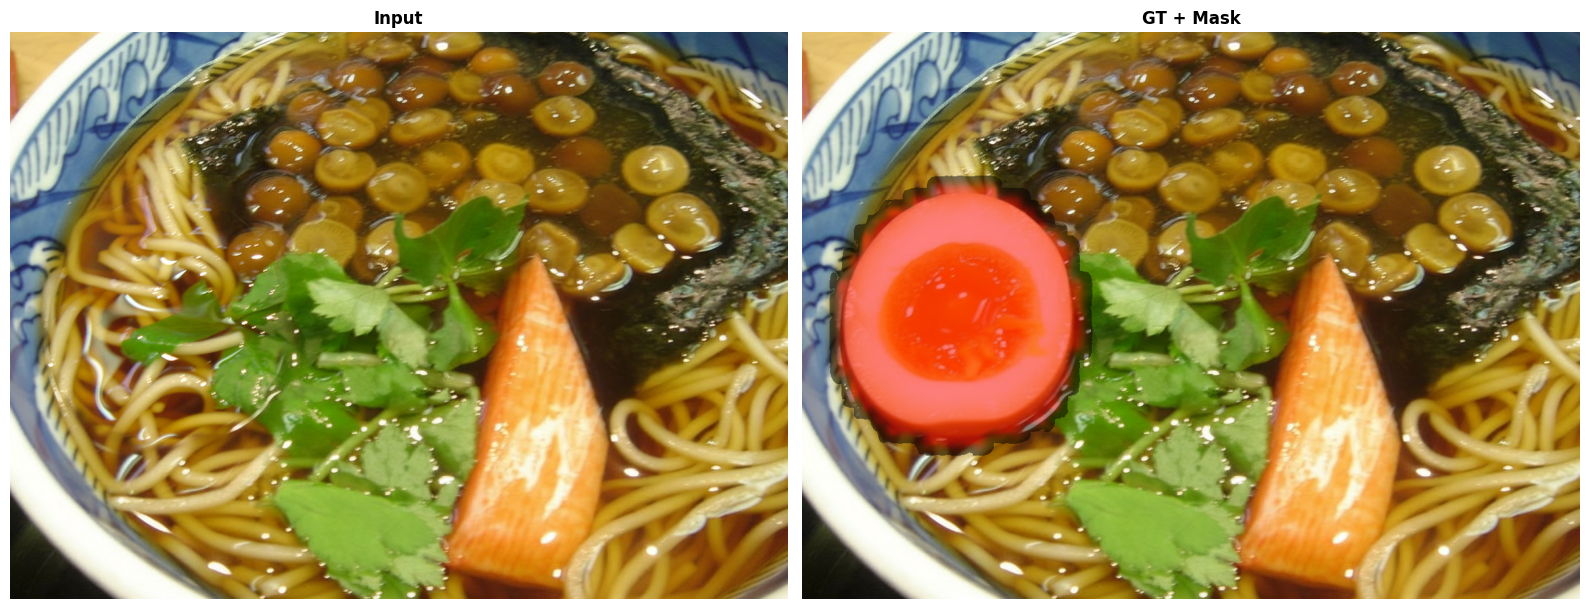


################################################################################
Edit Type: Add/Remove/Replace Accessories (glasses, hats, jewelry, masks) (共 53 个样本，显示 1 个)
################################################################################

样本索引: 869
编辑类型: Add/Remove/Replace Accessories (glasses, hats, jewelry, masks)

Prompt: Picture 1 is the image to modify. Replace the woman's current necklace with a delicate silver chain featuring a small, iridescent pearl pendant, ensuring the new jewelry catches the ambient light naturally and complements her existing attire, and simultaneously add a subtle, dark brown fedora with a thin leather band to the man, positioned slightly askew to suggest a casual, artistic flair, ensuring all added accessories integrate seamlessly with the outdoor lighting and overall image composition.


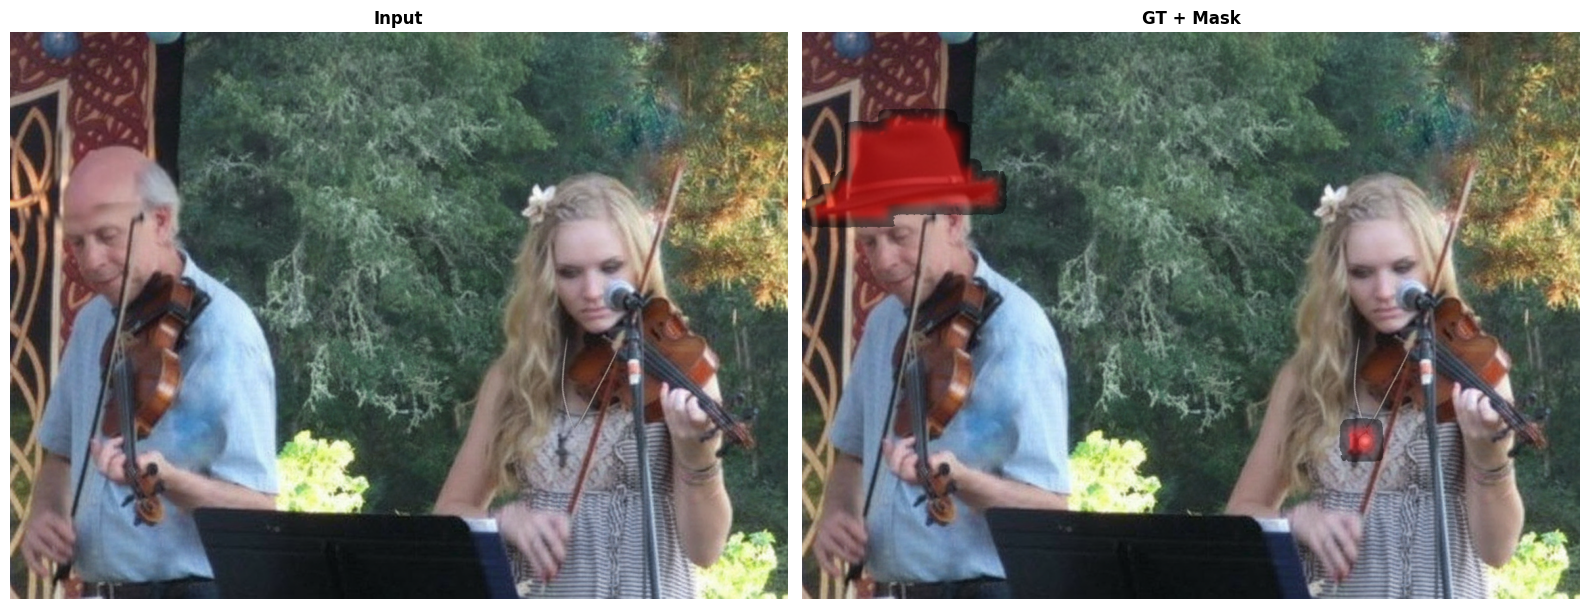


################################################################################
Edit Type: Clothing edit (change color/outfit) (共 49 个样本，显示 1 个)
################################################################################

样本索引: 793
编辑类型: Clothing edit (change color/outfit)

Prompt: Picture 1 is the image to modify. Change the man's suit jacket to deep navy and shirt to white, preserving shadows and textures naturally.


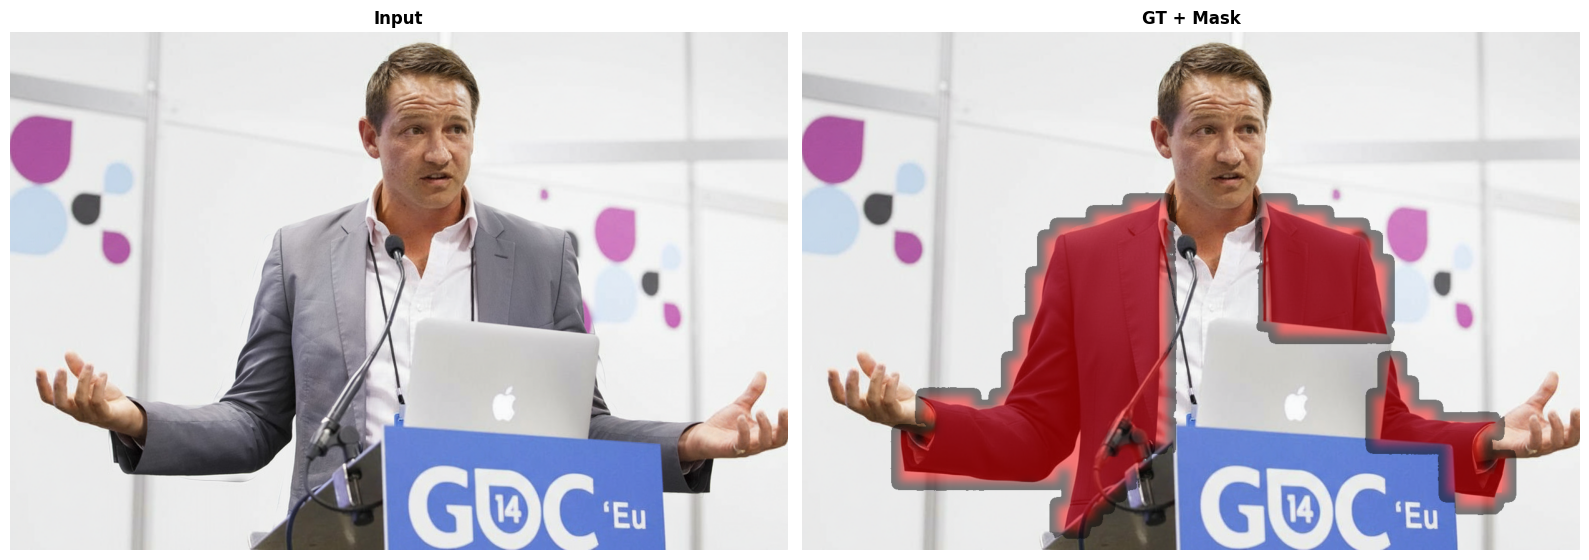


################################################################################
Edit Type: Remove an existing object (共 249 个样本，显示 1 个)
################################################################################

样本索引: 452
编辑类型: Remove an existing object

Prompt: Picture 1 is the image to modify. Remove the small orange boat and seamlessly extend the water surface, matching the calm, reflective texture and greyish-silver tones.


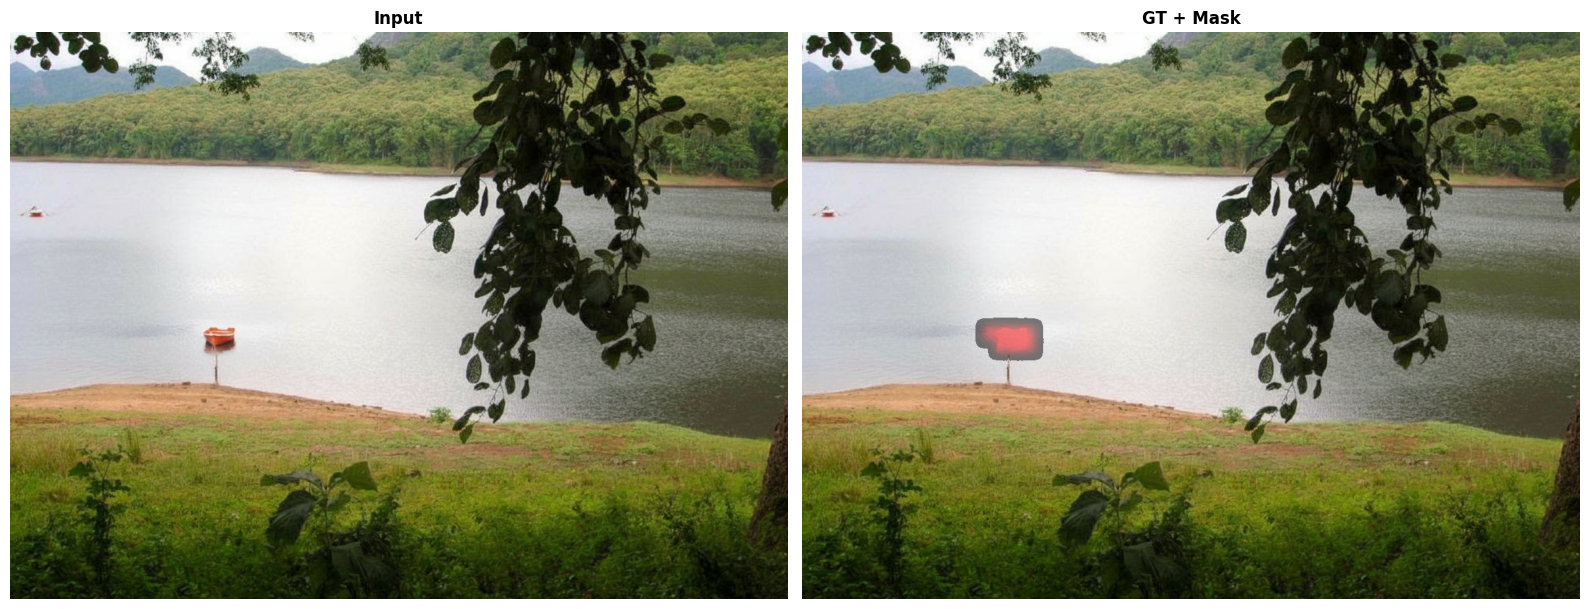


################################################################################
Edit Type: Replace one object category with another (共 302 个样本，显示 1 个)
################################################################################

样本索引: 752
编辑类型: Replace one object category with another

Prompt: Picture 1 is the image to modify. Add Lego construction vehicles like a bulldozer and excavator, matching the brick style and lighting.


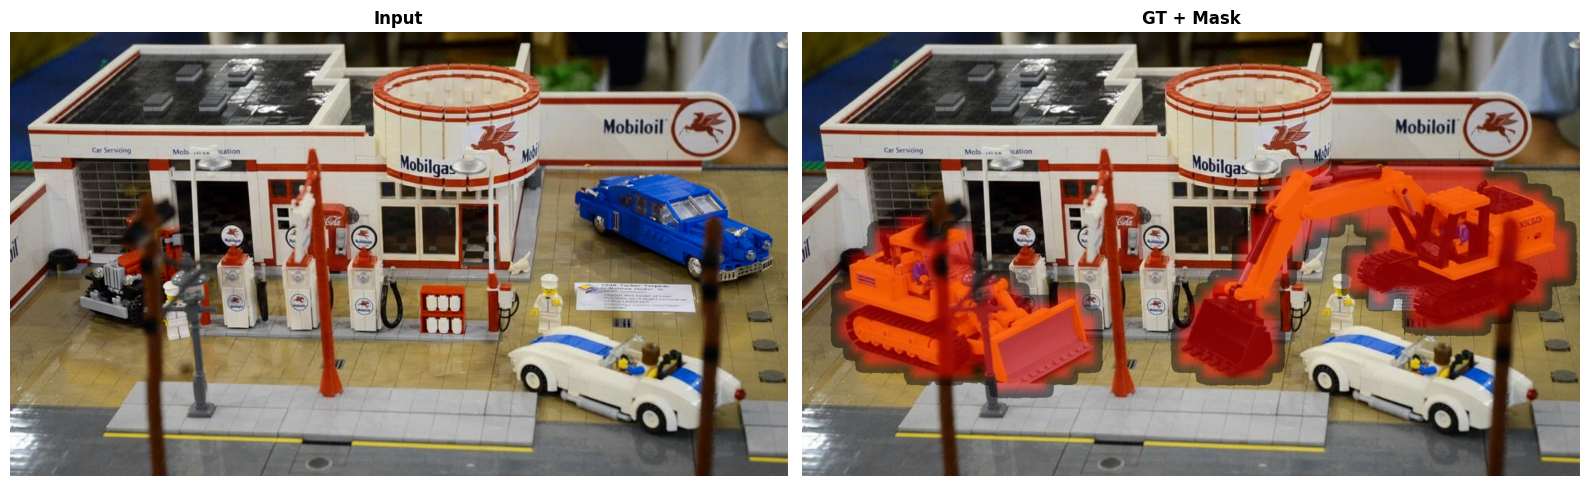

In [28]:
# 按 edit_type 查看样本
def view_samples_by_edit_type(samples_per_type=1):
    """每个 edit_type 显示指定数量的随机样本"""
    from collections import defaultdict
    
    grouped = defaultdict(list)
    for idx, sample in enumerate(dataset):
        grouped[sample.get('edit_type', 'Unknown')].append((idx, sample))
    
    for edit_type in sorted(grouped.keys()):
        samples = grouped[edit_type]
        print(f"\n{'#' * 80}")
        print(f"Edit Type: {edit_type} (共 {len(samples)} 个样本，显示 {min(samples_per_type, len(samples))} 个)")
        print(f"{'#' * 80}\n")
        chosen = random.sample(samples, k=min(samples_per_type, len(samples)))
        for idx, sample in chosen:
            visualize_sample(sample, index=idx)
            
# 每个 edit_type 查看一个样本
view_samples_by_edit_type(samples_per_type=1)

样本索引: 1
编辑类型: Remove an existing object

Prompt: Picture 1 is the image to modify. Remove the child and pony, replacing them with lush green grass matching the existing lawn.


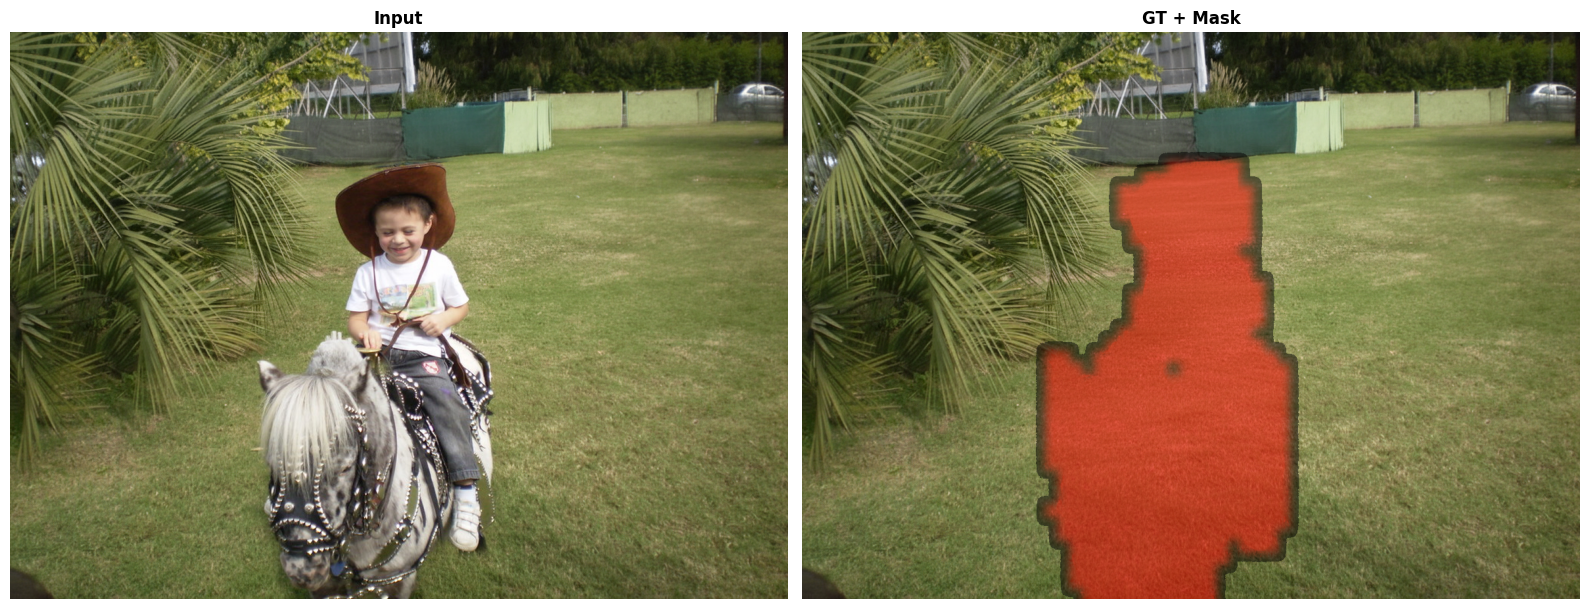

In [24]:
# 查看指定索引的样本
def view_sample_by_index(index):
    """查看指定索引的样本"""
    if 0 <= index < len(dataset):
        visualize_sample(dataset[index], index)
    else:
        print(f"错误: 索引 {index} 超出范围 [0, {len(dataset)-1}]")

# 示例：查看索引为 0 的样本
view_sample_by_index(1)